# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Richard Liestianto
- Email: richard.825230069@stu.untar.ac.id
- Id Dicoding: richard_liestianto

## Persiapan

### Menyiapkan library yang dibutuhkan

In [82]:
# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing dan machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Library untuk evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Library untuk menyimpan model
import joblib

# Library tambahan
import warnings
warnings.filterwarnings("ignore")

### Menyiapkan data yang akan diguankan

## Data Understanding

In [83]:
df = pd.read_csv("data.csv", sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [84]:
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

Jumlah baris : 4424
Jumlah kolom : 37


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [86]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Marital_status
2. Application_mode
3. Application_order
4. Course
5. Daytime_evening_attendance
6. Previous_qualification
7. Previous_qualification_grade
8. Nacionality
9. Mothers_qualification
10. Fathers_qualification
11. Mothers_occupation
12. Fathers_occupation
13. Admission_grade
14. Displaced
15. Educational_special_needs
16. Debtor
17. Tuition_fees_up_to_date
18. Gender
19. Scholarship_holder
20. Age_at_enrollment
21. International
22. Curricular_units_1st_sem_credited
23. Curricular_units_1st_sem_enrolled
24. Curricular_units_1st_sem_evaluations
25. Curricular_units_1st_sem_approved
26. Curricular_units_1st_sem_grade
27. Curricular_units_1st_sem_without_evaluations
28. Curricular_units_2nd_sem_credited
29. Curricular_units_2nd_sem_enrolled
30. Curricular_units_2nd_sem_evaluations
31. Curricular_units_2nd_sem_approved
32. Curricular_units_2nd_sem_grade
33. Curricular_units_2nd_sem_without_evaluations
34. Unemployment_rate
35. Inflation_rate
36. GDP
37. Status


In [87]:
missing_values = df.isnull().sum()

print(f"Total missing values: {missing_values.sum()}")

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [88]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Jumlah data duplikat     : {duplicate_count}")
print(f"Persentase data duplikat : {duplicate_percentage:.2f}%")

Jumlah data duplikat     : 0
Persentase data duplikat : 0.00%


In [89]:
print("Kategori pada variabel Status:")
print(df["Status"].unique())

Kategori pada variabel Status:
['Dropout' 'Graduate' 'Enrolled']


In [90]:
status_distribution = pd.DataFrame({
    "Jumlah": df["Status"].value_counts(),
    "Persentase (%)": df["Status"].value_counts(normalize=True).mul(100).round(2)
})

status_distribution

,Jumlah,Persentase (%)
Status,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


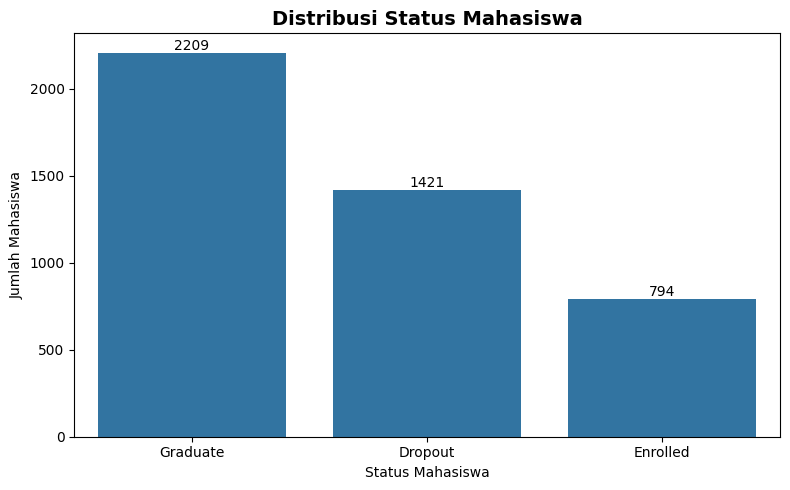

In [91]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Status",
    order=df["Status"].value_counts().index
)

plt.title("Distribusi Status Mahasiswa", fontsize=14, fontweight="bold")
plt.xlabel("Status Mahasiswa")
plt.ylabel("Jumlah Mahasiswa")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [92]:
unique_summary = pd.DataFrame({
    "Fitur": df.columns,
    "Jumlah Nilai Unik": [df[column].nunique() for column in df.columns],
    "Tipe Data": [df[column].dtype for column in df.columns]
})

unique_summary

,Fitur,Jumlah Nilai Unik,Tipe Data
0,Marital_status,6,int64
1,Application_mode,18,int64
2,Application_order,8,int64
3,Course,17,int64
4,Daytime_evening_attendance,2,int64
5,Previous_qualification,17,int64
6,Previous_qualification_grade,101,float64
7,Nacionality,21,int64
8,Mothers_qualification,29,int64
9,Fathers_qualification,34,int64


In [93]:
numerical_features = [
    "Application_order",
    "Previous_qualification_grade",
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_credited",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
    "Curricular_units_2nd_sem_credited",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations",
    "Unemployment_rate",
    "Inflation_rate",
    "GDP"
]

df[numerical_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Application_order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission_grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age_at_enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular_units_1st_sem_credited,4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular_units_1st_sem_enrolled,4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular_units_1st_sem_evaluations,4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular_units_1st_sem_approved,4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular_units_1st_sem_grade,4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular_units_1st_sem_without_evaluations,4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00


In [94]:
key_numerical_features = [
    "Age_at_enrollment",
    "Admission_grade",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
]

status_numerical_summary = (
    df.groupby("Status")[key_numerical_features]
    .mean()
    .round(2)
)

status_numerical_summary

,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Status,,,,,,
Dropout,26.07,124.96,2.55,7.26,1.94,5.90
Enrolled,22.37,125.53,4.32,11.13,4.06,11.12
Graduate,21.78,128.79,6.23,12.64,6.18,12.70


**Insight Perbandingan Berdasarkan Status:**

Hasil perbandingan menunjukkan adanya perbedaan karakteristik yang cukup jelas antara mahasiswa berstatus **Dropout**, **Enrolled**, dan **Graduate**.

Mahasiswa yang mengalami **Dropout** memiliki rata-rata usia saat mendaftar sebesar **26,07 tahun**, lebih tinggi dibanding mahasiswa Enrolled sebesar **22,37 tahun** dan Graduate sebesar **21,78 tahun**.

Perbedaan yang lebih mencolok terlihat pada performa akademik. Mahasiswa Dropout rata-rata hanya menyelesaikan **2,55 unit kurikuler pada semester pertama** dan **1,94 unit pada semester kedua**, sedangkan mahasiswa Graduate rata-rata menyelesaikan masing-masing **6,23** dan **6,18 unit**.

Rata-rata nilai semester mahasiswa Dropout juga lebih rendah, yaitu **7,26 pada semester pertama** dan **5,90 pada semester kedua**. Sebagai perbandingan, mahasiswa Graduate memiliki rata-rata nilai sebesar **12,64** dan **12,70**.

Temuan awal ini menunjukkan bahwa **performa akademik semester awal berpotensi menjadi indikator penting dalam mengidentifikasi risiko dropout** dan layak dianalisis lebih lanjut pada tahapan berikutnya.


## Data Preparation / Preprocessing

In [95]:
# Memisahkan mahasiswa yang sudah memiliki status akhir
df_model = df[df["Status"].isin(["Dropout", "Graduate"])].copy()

# Menyimpan mahasiswa Enrolled sebagai data untuk prediksi di masa depan
df_enrolled = df[df["Status"] == "Enrolled"].copy()

print("Data untuk modeling :", df_model.shape)
print("Data Enrolled       :", df_enrolled.shape)

print("\nDistribusi data modeling:")
print(df_model["Status"].value_counts())

Data untuk modeling : (3630, 37)
Data Enrolled       : (794, 37)

Distribusi data modeling:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [96]:
df_model["Dropout"] = df_model["Status"].map({
    "Graduate": 0,
    "Dropout": 1
})

In [97]:
X = df_model.drop(columns=["Status", "Dropout"])
y = df_model["Dropout"]

print("Jumlah data modeling :", len(X))
print("Jumlah fitur         :", X.shape[1])

print("\nDistribusi target:")
print(y.value_counts())

Jumlah data modeling : 3630
Jumlah fitur         : 36

Distribusi target:
Dropout
0    2209
1    1421
Name: count, dtype: int64


In [98]:
categorical_features = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print(f"Jumlah fitur kategorikal : {len(categorical_features)}")
print(f"Jumlah fitur numerik     : {len(numerical_features)}")

Jumlah fitur kategorikal : 17
Jumlah fitur numerik     : 19


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data training : {X_train.shape}")
print(f"Data testing  : {X_test.shape}")

Data training : (2904, 36)
Data testing  : (726, 36)


In [100]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Modeling

In [101]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [102]:
logistic_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

print("Logistic Regression berhasil dilatih.")
print("Random Forest berhasil dilatih.")

Logistic Regression berhasil dilatih.
Random Forest berhasil dilatih.


## Evaluation

In [103]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

evaluation_results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.934,0.91,0.923,0.916,0.976
1,Random Forest,0.930,0.94,0.877,0.907,0.973


In [104]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n=== {model_name} ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Graduate", "Dropout"]
    ))


=== Logistic Regression ===
              precision    recall  f1-score   support

    Graduate       0.95      0.94      0.95       442
     Dropout       0.91      0.92      0.92       284

    accuracy                           0.93       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.93      0.93      0.93       726


=== Random Forest ===
              precision    recall  f1-score   support

    Graduate       0.92      0.96      0.94       442
     Dropout       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.93       726
weighted avg       0.93      0.93      0.93       726



In [105]:
best_model_name = evaluation_df.loc[
    evaluation_df["F1-Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print(f"Model terbaik berdasarkan F1-Score: {best_model_name}")

Model terbaik berdasarkan F1-Score: Logistic Regression


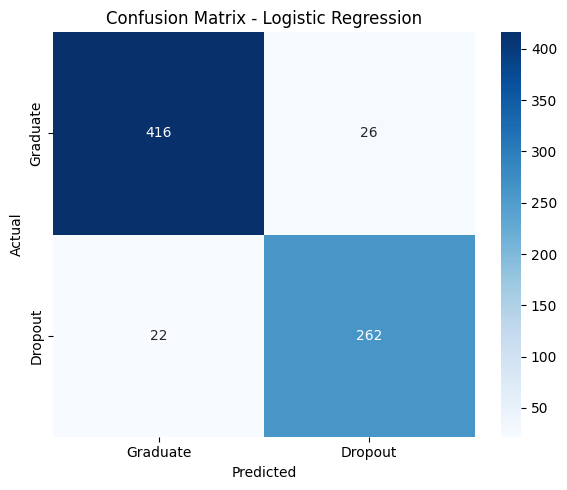

In [106]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Graduate", "Dropout"],
    yticklabels=["Graduate", "Dropout"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [107]:
# Menyiapkan data mahasiswa yang masih Enrolled untuk prediksi
X_enrolled = df_enrolled[X.columns].copy()

# Melakukan prediksi menggunakan model terbaik
enrolled_prediction = best_model.predict(X_enrolled)
enrolled_probability = best_model.predict_proba(X_enrolled)[:, 1]

# Menyimpan hasil prediksi
enrolled_results = df_enrolled.copy()

enrolled_results["Predicted_Status"] = np.where(
    enrolled_prediction == 1,
    "Dropout",
    "Graduate"
)

enrolled_results["Dropout_Probability"] = enrolled_probability

enrolled_results[
    ["Predicted_Status", "Dropout_Probability"]
].head()

,Predicted_Status,Dropout_Probability
16,Dropout,0.954671
19,Graduate,0.441660
21,Graduate,0.041895
25,Graduate,0.203677
27,Graduate,0.053476


**Evaluation Summary:**

Setelah proses modeling diperbaiki dengan hanya menggunakan mahasiswa berstatus **Graduate** dan **Dropout**, Logistic Regression dan Random Forest dievaluasi menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

Berdasarkan hasil evaluasi, **Logistic Regression** menghasilkan Accuracy sebesar **93,4%**, Precision sebesar **91,0%**, Recall sebesar **92,3%**, F1-Score sebesar **91,6%**, dan ROC-AUC sebesar **97,6%**.

Sementara itu, **Random Forest** menghasilkan Accuracy sebesar **93,0%**, Precision sebesar **94,0%**, Recall sebesar **87,7%**, F1-Score sebesar **90,7%**, dan ROC-AUC sebesar **97,3%**.

Random Forest memiliki Precision yang lebih tinggi dalam memprediksi mahasiswa Dropout. Namun, Logistic Regression memiliki **Recall, F1-Score, Accuracy, dan ROC-AUC yang lebih tinggi**. Dalam konteks deteksi dropout, Recall menjadi metrik yang penting karena menunjukkan kemampuan model dalam mengidentifikasi mahasiswa yang benar-benar termasuk dalam kelas Dropout. Recall yang lebih tinggi membantu mengurangi jumlah mahasiswa berisiko dropout yang tidak terdeteksi.

Berdasarkan hasil tersebut, **Logistic Regression dipilih sebagai model final** karena memberikan performa yang lebih seimbang dalam membedakan mahasiswa yang berpotensi **Dropout** dan **Graduate**.


In [108]:
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(
    best_model,
    "model/dropout_prediction_model.joblib"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.
